# 🌾 FarmTech Solutions  

## Machine Learning Aplicado ao Agronegócio



**Instituição:** FIAP  
**Fase:** 5  
**Turma:** TIAOR  
**Entrega:** 1 — Machine Learning  
**Alunos:**   
__Estevão Ferreira Santos - RM567522  
__Durval de Oliveira Dorta Junior - RM567007  
__Murilo Ferreira Borges - RM567738  
__Guilherme Cury - RM564011  
__Guilherme da Nóbrega Gontijo - RM562211

            

## 📋 Descrição do Projeto

Este projeto representa a **Entrega 1 (Machine Learning na Cabeça)** da Fase 5

####Contexto  
A **FarmTech Solutions** é uma empresa de consultoria em Inteligência Artificial
que presta serviços para o agronegócio. Neste projeto, fomos contratados por
uma **fazenda de médio porte**, com aproximadamente **200 hectares**
(equivalente a cerca de 210 campos de futebol oficiais), que produz diferentes
tipos de culturas agrícolas.  
O grande desafio desta fazenda é entender como as **condições climáticas e
ambientais** influenciam a **produtividade das colheitas**, a fim de planejar
melhor cada safra, reduzir perdas e maximizar o rendimento.



Este notebook tem como objetivo analisar uma base de dados agrícola
(**crop_yield.csv**) contendo informações sobre condições climáticas e
rendimento de safras

##🎯 Objetivos do Projeto

Este notebook tem como objetivos principais:  

1. **Análise Exploratória de Dados (EDA):** Familiarização com a base de dados para entender a distribuição das variáveis e o comportamento das safras.
2. **Machine Learning Sem Supervisão (Descoberta de Dados):** Exploração de tendências de produtividade por meio de algoritmos de clusterização (K-Means e DBSCAN), visando encontrar tendências para os rendimentos das plantações e identificar cenários discrepantes (outliers).
3. **Modelagem de Dados com Regressão Supervisionada:** Desenvolvimento, treinamento e avaliação de **modelos preditivos distintos**. O objetivo é que, dadas as condições climáticas, os modelos prevejam com precisão qual será o rendimento da safra, seguindo rigorosamente as boas práticas de projetos de Machine Learning e utilizando métricas de avaliação pertinentes.

---
## 📚 1. Configuração do Ambiente e Importação de Bibliotecas

Antes de iniciarmos a manipulação dos dados, precisamos preparar o nosso ambiente de desenvolvimento.  

Nessa etapa fizemos as importações e instalações das bibliotecas necessarias para o projeto

Isso garante a reprodutibilidade do código e deixa claro para o leitor quais ferramentas compõem a nossa solução.

In [3]:
# ==============================================================================
# 1. BIBLIOTECAS DE MANIPULAÇÃO E VISUALIZAÇÃO DE DADOS
# ==============================================================================
import pandas as pd                  # Manipulação de dados em formato tabular (DataFrames)
import numpy as np                   # Operações matemáticas e manipulação de arrays
import matplotlib.pyplot as plt      # Criação de gráficos e visualizações base
import seaborn as sns                # Visualizações estatísticas avançadas e estéticas

# Configuração global para o design dos gráficos do projeto
sns.set_theme(style="whitegrid", palette="muted")

# ==============================================================================
# 2. BIBLIOTECAS DE PRÉ-PROCESSAMENTO E VALIDAÇÃO
# ==============================================================================
from sklearn.model_selection import train_test_split  # Divisão do dataset em Treino e Teste
from sklearn.preprocessing import StandardScaler      # Padronização de escala (Z-score)
from sklearn.preprocessing import OneHotEncoder       # Transformação de variáveis categóricas

# ==============================================================================
# 3. ALGORITMOS DE APRENDIZADO NÃO SUPERVISIONADO (CLUSTERIZAÇÃO)
# ==============================================================================
from sklearn.cluster import KMeans           # Algoritmo para identificação de tendências/grupos
from sklearn.cluster import DBSCAN           # Algoritmo baseado em densidade para achar outliers
from sklearn.metrics import silhouette_score # Métrica para avaliar a coesão dos clusters

# ==============================================================================
# 4. ALGORITMOS DE APRENDIZADO SUPERVISIONADO (REGRESSÃO)
# ==============================================================================
from sklearn.linear_model import LinearRegression      # Modelo 1: Regressão Linear (Baseline)
from sklearn.tree import DecisionTreeRegressor         # Modelo 2: Árvore de Decisão
from sklearn.ensemble import RandomForestRegressor     # Modelo 3: Floresta Aleatória
from sklearn.svm import SVR                            # Modelo 4: Máquinas de Vetores de Suporte
from sklearn.ensemble import GradientBoostingRegressor # Modelo 5: Gradient Boosting

# ==============================================================================
# 5. MÉTRICAS DE AVALIAÇÃO DE DESEMPENHO
# ==============================================================================
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ignorando avisos (warnings) não críticos para manter a apresentação limpa
import warnings
warnings.filterwarnings('ignore')

##📊 2. Análise Exploratória dos Dados (EDA)
A Análise Exploratória de Dados (EDA) é o primeiro passo fundamental em qualquer projeto de Machine Learning. Antes de treinar qualquer modelo, precisamos entender profundamente os dados com os quais estamos trabalhando.

Nesta seção iremos:

Carregar e visualizar o dataset  
Verificar a estrutura e qualidade dos dados  
Identificar valores nulos e duplicatas  
Analisar estatísticas descritivas  
Visualizar distribuições e correlações entre variáveis  

*importe a base de dados "crop_yield.csv" para dar início a essa etapa

In [5]:
# lendo o arquivo e exibindo as 5 primeiras linhas
df = pd.read_csv('crop_yield.csv')
display(df.head())


,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


In [6]:
# Exibindo um resumo estrutural do dataset (linhas, colunas e tipos de dados)
print("\n--- Resumo Estrutural do Dataset ---")
df.info()


--- Resumo Estrutural do Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    object 
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.4+ KB


In [7]:
# Verificando valores nulos e duplicados
print("--- Verificação de Qualidade dos Dados ---")
print(f"Valores Nulos:\n{df.isnull().sum()}\n")
print(f"Linhas Duplicadas: {df.duplicated().sum()}\n")

--- Verificação de Qualidade dos Dados ---
Valores Nulos:
Crop                                    0
Precipitation (mm day-1)                0
Specific Humidity at 2 Meters (g/kg)    0
Relative Humidity at 2 Meters (%)       0
Temperature at 2 Meters (C)             0
Yield                                   0
dtype: int64

Linhas Duplicadas: 0



In [9]:
# Quantidade de registros por cultura
qtd_por_cultura = df['Crop'].value_counts()
display(qtd_por_cultura.to_frame('Quantidade'))

,Quantidade
Crop,
"Cocoa, beans",39
Oil palm fruit,39
"Rice, paddy",39
"Rubber, natural",39


In [11]:
# Gerando estatísticas descritivas (média, desvio padrão, quartis)
display(df.describe())

,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
count,156.000000,156.000000,156.000000,156.00000,156.000000
mean,2486.498974,18.203077,84.737692,26.18359,56153.096154
std,289.457914,0.293923,0.996226,0.26105,70421.958897
min,1934.620000,17.540000,82.110000,25.56000,5249.000000
25%,2302.990000,18.030000,84.120000,26.02000,8327.750000
50%,2424.550000,18.270000,84.850000,26.13000,18871.000000
75%,2718.080000,18.400000,85.510000,26.30000,67518.750000
max,3085.790000,18.700000,86.100000,26.81000,203399.000000


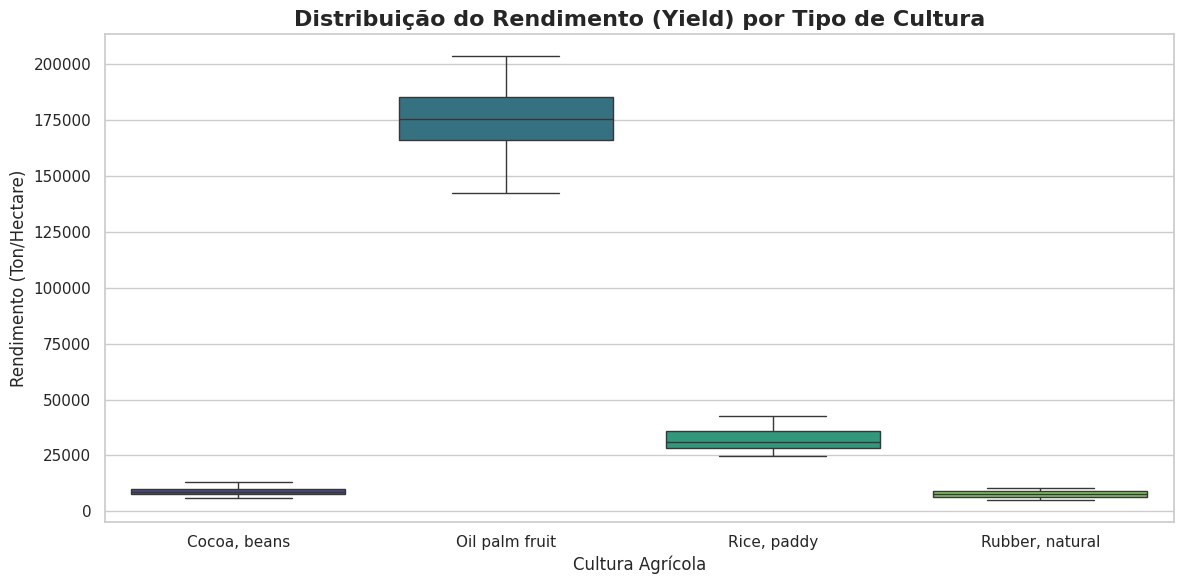

In [12]:
# VISUALIZAÇÃO 1: Distribuição do Rendimento por Cultura
# ==============================================================================
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Crop', y='Yield', palette='viridis')
plt.title('Distribuição do Rendimento (Yield) por Tipo de Cultura', fontsize=16, fontweight='bold')
plt.xlabel('Cultura Agrícola', fontsize=12)
plt.ylabel('Rendimento (Ton/Hectare)', fontsize=12)
plt.xticks(fontsize=11)
plt.tight_layout()
plt.show()

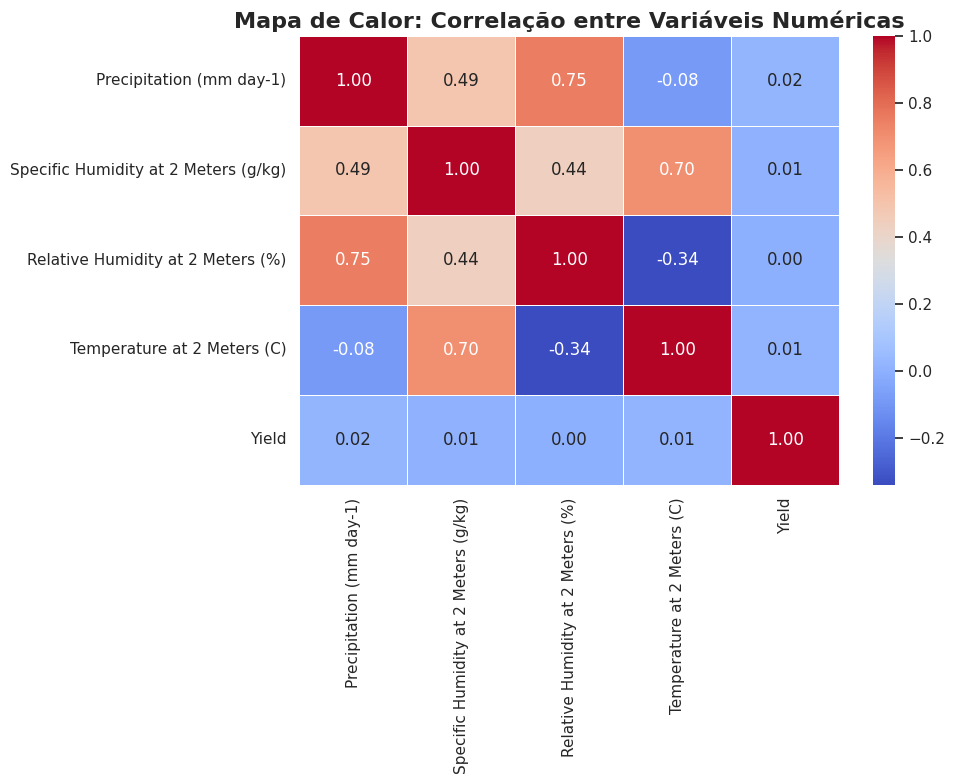

In [13]:
# VISUALIZAÇÃO 2: Mapa de Calor de Correlação (Apenas variáveis numéricas)
# ==============================================================================
plt.figure(figsize=(10, 8))
# Selecionando apenas as colunas numéricas para a correlação
colunas_numericas = df.select_dtypes(include=[np.number])
matriz_correlacao = colunas_numericas.corr()

# exibindo o mapa de calor
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Mapa de Calor: Correlação entre Variáveis Numéricas', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.1 Observações da Análise Exploratória de Dados (EDA)

Nesta etapa, mergulhamos nos dados fornecidos pela FarmTech Solutions para compreender o comportamento das variáveis antes de aplicarmos qualquer algoritmo de Machine Learning.

#### Descrição do Dataset (Dicionário de Dados)
A base de dados `crop_yield.csv` é composta por 156 registros e 6 colunas, representando o histórico de plantio de uma fazenda de 200 hectares. As variáveis são:
* **`Crop` (Cultura):** Nome da safra cultivada (Cacau, Óleo de Palma, Arroz ou Borracha). *Variável Categórica.*
* **`Precipitation` (Precipitação):** Volume de chuva em milímetros por dia (mm dia-1).
* **`Specific Humidity` (Umidade Específica):** Vapor de água no ar (g/kg) a 2 metros do solo.
* **`Relative Humidity` (Umidade Relativa):** Porcentagem (%) de vapor de água a 2 metros do solo.
* **`Temperature` (Temperatura):** Temperatura em graus Celsius (ºC) a 2 metros do solo.
* **`Yield` (Rendimento):** Produção em toneladas por hectare. **(Nossa Variável Alvo / Target)**.

#### Qualidade e Saúde dos Dados
A inspeção inicial (`info`, `isnull`, `duplicated`) revelou um cenário ideal:
* **Integridade:** Temos 0 valores nulos e 0 linhas duplicadas. Não será necessário aplicar técnicas de imputação (preenchimento sintético).
* **Balanceamento:** A base possui 39 registros para cada uma das 4 culturas, garantindo que os modelos não favoreçam uma planta em detrimento de outra por desbalanceamento amostral.

#### Análise Estatística Descritiva
A função `describe()` nos trouxe insights valiosos sobre o clima da fazenda:
* **Estabilidade Climática:** A fazenda apresenta um clima tropical estável. A temperatura varia em uma faixa muito estreita (mínima de 25.5ºC e máxima de 26.8ºC). A umidade relativa também é alta e constante (média de 84.7%).
* **Alta Variância no Rendimento:** Enquanto o clima é estável, o desvio padrão da coluna `Yield` é gigantesco (70.421), indicando que a produção flutua drasticamente. O motivo dessa flutuação é explicado na análise visual abaixo.

#### Achados Visuais (Insights para a Modelagem)

**. (Boxplot de Rendimento por Cultura)**
O gráfico de caixas (Boxplot) responde o motivo da alta variância no rendimento. As culturas operam em escalas de grandeza completamente diferentes:
1. *Borracha (Rubber)* e *Cacau (Cocoa)*: Baixo volume (5.000 a 13.000 ton/ha).
2. *Arroz (Rice)*: Volume médio (25.000 a 40.000 ton/ha).
3. *Óleo de Palma (Oil palm fruit)*: Volume massivo (140.000 a 200.000 ton/ha).
* **Decisão Técnica:** Esta discrepância torna essencial a padronização dos dados (via `StandardScaler`). Se aplicarmos algoritmos baseados em distância (como K-Means e DBSCAN) nos dados brutos, a matemática do algoritmo será "esmagada" pelos números do Óleo de Palma, ignorando as outras culturas.

**. (Mapa de Calor)**
O Heatmap revelou:
* **Correlações Climáticas:** Existe forte correlação positiva entre Precipitação e Umidade Relativa (0.75), e entre Temperatura e Umidade Específica (0.70), o que é meteorologicamente lógico.
* **Correlação com o Alvo (Yield):** A correlação linear de *todas* as variáveis climáticas com o `Yield` é praticamente **zero** (variando de 0.00 a 0.02).
* **Decisão Técnica:** Isso não significa que o clima não afeta a planta! Isso ocorre porque estamos analisando 4 plantas diferentes juntas. O clima que faz o Arroz render muito pode ser o mesmo que faz o Cacau render pouco, anulando a correlação matemática global. Isso justifica a necessidade de transformarmos a coluna `Crop` em números (One-Hot Encoding) e utilizarmos modelos não-lineares robustos (como Random Forest e Gradient Boosting) na fase de regressão.

---
## 🧩 3. Aprendizado Não Supervisionado (Clusterização)

Nesta etapa, utilizaremos algoritmos de clusterização para descobrir padrões ocultos nos dados, sem a influência da variável alvo (`Yield`) na formação inicial dos grupos climáticos.

**Estratégia Adotada:**
1. **Pré-processamento:** Padronização (`StandardScaler`) das variáveis numéricas, passo obrigatório para algoritmos baseados em cálculo de distância euclidiana.
2. **K-Means (Tendências):** Agruparemos os dados baseados *apenas* nas condições climáticas para criar "Perfis Climáticos". Em seguida, analisaremos como o rendimento (`Yield`) se comporta dentro de cada perfil.
3. **DBSCAN (Outliers):** Utilizaremos este algoritmo baseado em densidade para identificar registros anômalos (ruídos), que representam cenários discrepantes de clima ou produção.

In [14]:
# ==============================================================================
# 1. PRÉ-PROCESSAMENTO E PRAPARAÇÃO DOS DADOS (PADRONIZAÇÃO)
# ==============================================================================
# Definindo as colunas que vamos utilizar
features_climaticas = ['Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)',
                       'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)']
features_numericas_todas = features_climaticas + ['Yield']

# Instanciando o padronizador
scaler = StandardScaler()

# Criando DataFrames padronizados (reconstruindo como DataFrame para manter os nomes das colunas)
df_clima_scaled = pd.DataFrame(scaler.fit_transform(df[features_climaticas]), columns=features_climaticas)
df_all_scaled = pd.DataFrame(scaler.fit_transform(df[features_numericas_todas]), columns=features_numericas_todas)

# Exibindo o DataFrame padronizado conforme solicitado
print("--- Visualização dos Dados Padronizados (Z-score) ---")
print("Note que os valores agora orbitam em torno de 0 (média) com desvio padrão 1.")
print("Isso elimina o problema da diferença de escala entre Clima e Yield.")
display(df_all_scaled.head())

--- Visualização dos Dados Padronizados (Z-score) ---
Note que os valores agora orbitam em torno de 0 (média) com desvio padrão 1.
Isso elimina o problema da diferença de escala entre Clima e Yield.


,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,-0.823415,-1.648845,-1.347084,-0.667109,-0.635267
1,-1.899565,-2.263223,-2.646141,-0.282807,-0.639640
2,-0.641042,-1.341656,-1.961367,0.216786,-0.665240
3,0.366865,-2.024299,0.334641,-2.396470,-0.667163
4,-0.491386,-2.024299,-0.622029,-1.627865,-0.674585


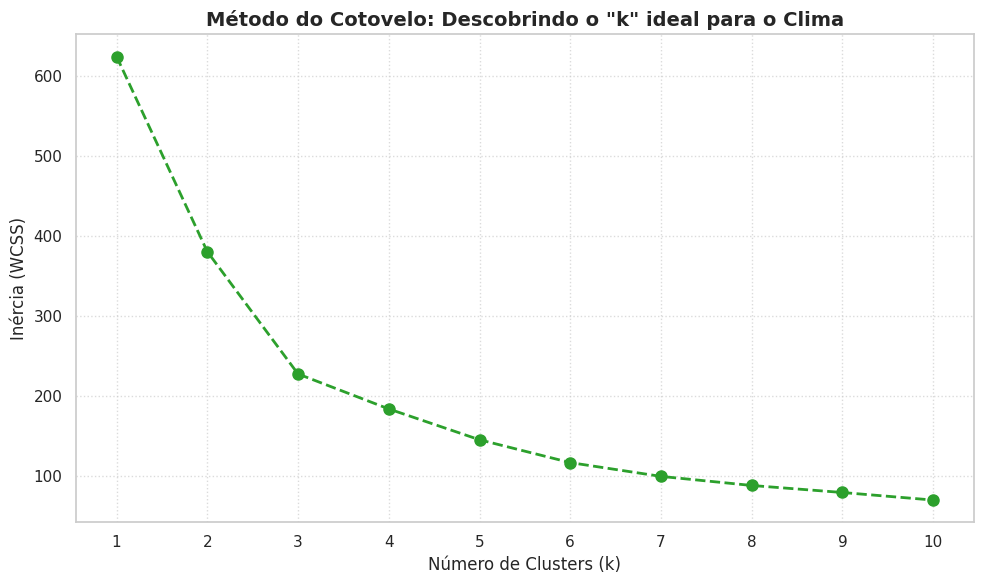

In [15]:
# ==============================================================================
# 2. O MÉTODO DO COTOVELO (ELBOW METHOD) PARA O K-MEANS
# ==============================================================================
# Lista para guardar a inércia (soma dos quadrados das distâncias dentro do cluster)
wcss = []

# Testando o K-Means para valores de k entre 1 e 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(df_clima_scaled) # Treinando apenas com os dados climáticos padronizados
    wcss.append(kmeans.inertia_)

# Plotando o gráfico do Método do Cotovelo
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='#2ca02c', linewidth=2, markersize=8)
plt.title('Método do Cotovelo: Descobrindo o "k" ideal para o Clima', fontsize=14, fontweight='bold')
plt.xlabel('Número de Clusters (k)', fontsize=12)
plt.ylabel('Inércia (WCSS)', fontsize=12)
plt.xticks(range(1, 11))
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

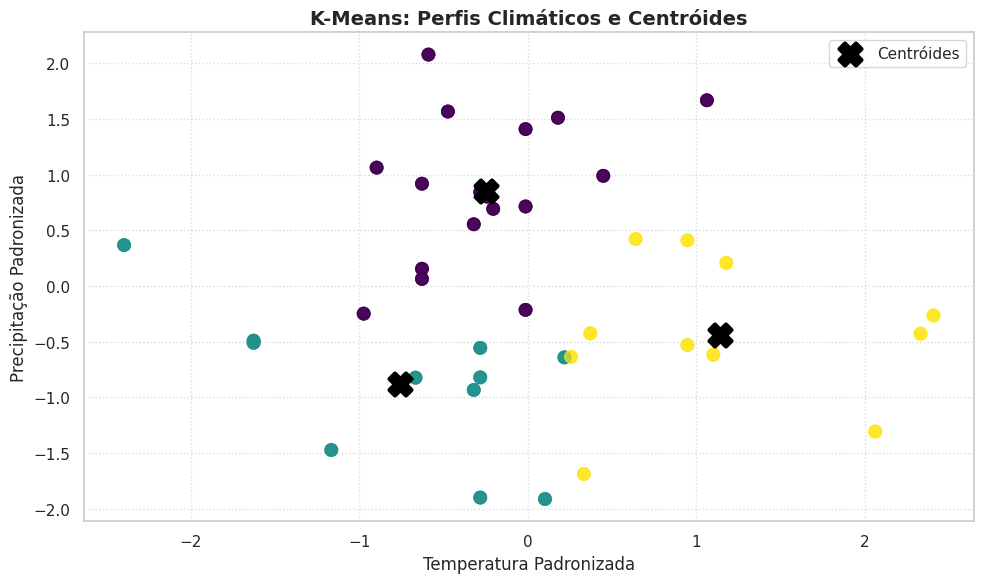


--- Tendência de Rendimento por Perfil Climático ---


,Yield,Temperature at 2 Meters (C),Precipitation (mm day-1)
Perfil_Climatico,,,
0,56736.54,26.12,2733.52
1,53951.50,25.99,2232.22
2,57453.00,26.48,2359.02


In [16]:
# ==============================================================================
# 3. APLICANDO K-MEANS (k=3) COM PLOTAGEM DE CENTRÓIDES
# ==============================================================================
# Instancia o algoritmo com k=3 (conforme nosso Método do Cotovelo)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Implementa o k-means sobre os dados climáticos padronizados
kmeans.fit(df_clima_scaled)

# Obtém os centroids do método (terão 4 dimensões, pois usamos 4 variáveis)
centroids = kmeans.cluster_centers_

# Salva os labels (grupos) dos clusters para cada exemplo no nosso DataFrame original
df['Perfil_Climatico'] = kmeans.predict(df_clima_scaled)

# --- VISUALIZAÇÃO DO K-MEANS ---
plt.figure(figsize=(10, 6))

# Plotando a clusterização (Usando Temperatura no X e Precipitação no Y)
plt.scatter(df_clima_scaled["Temperature at 2 Meters (C)"],
            df_clima_scaled["Precipitation (mm day-1)"],
            c=df['Perfil_Climatico'],
            alpha=0.6, cmap="viridis", s=80)

# Plotando os centroides (Índice 3 é a Temperatura, Índice 0 é a Precipitação)
plt.scatter(centroids[:, 3], centroids[:, 0],
            c="black", marker="X", s=250, linewidths=3, label="Centróides")

plt.title('K-Means: Perfis Climáticos e Centróides', fontsize=14, fontweight='bold')
plt.xlabel("Temperatura Padronizada")
plt.ylabel("Precipitação Padronizada")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# Resumo dos achados do K-Means
tendencia = df.groupby('Perfil_Climatico')[['Yield', 'Temperature at 2 Meters (C)', 'Precipitation (mm day-1)']].mean().round(2)
print("\n--- Tendência de Rendimento por Perfil Climático ---")
display(tendencia)

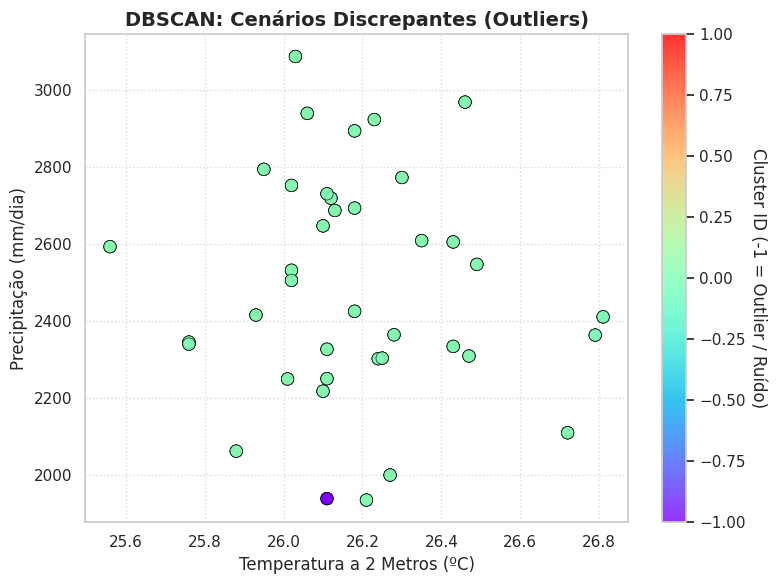


Total de Outliers (Cenários Discrepantes) encontrados pelo DBSCAN: 6


In [17]:
# ==============================================================================
# 4. APLICANDO DBSCAN PARA ACHAR OUTLIERS
# ==============================================================================
# Instancia o algoritmo com os parâmetros ajustados para dados padronizados
dbscan = DBSCAN(eps=1.5, min_samples=5)

# Roda o algoritmo sobre TODAS as variáveis padronizadas (Clima + Yield)
dbscan.fit(df_all_scaled)

# Obtém as atribuições dos pontos
dbscan_labels = dbscan.labels_

# Salva os labels no dataframe original para podermos contar depois
df['Outlier_DBSCAN'] = dbscan_labels

# --- VISUALIZAÇÃO ---
plt.figure(figsize=(8, 6))

# Plotando (Usando as colunas originais do df para evitar erros de índice)
plt.scatter(df['Temperature at 2 Meters (C)'],       # Eixo X (Temperatura Real)
            df['Precipitation (mm day-1)'],          # Eixo Y (Precipitação Real)
            c=dbscan_labels,                         # Esquema de cores baseado nos clusters/outliers
            alpha=0.8,                               # Transparência dos pontos
            cmap="rainbow",                          # Paleta de cores (conforme seu código)
            s=80,                                    # Tamanho dos pontos
            edgecolors='black',                      # Borda preta nos pontos para destacar
            linewidth=0.5)

plt.title('DBSCAN: Cenários Discrepantes (Outliers)', fontsize=14, fontweight='bold')
plt.xlabel("Temperatura a 2 Metros (ºC)")
plt.ylabel("Precipitação (mm/dia)")

# Adicionando uma barra de cores para o avaliador entender que -1 é o outlier
cbar = plt.colorbar()
cbar.set_label('Cluster ID (-1 = Outlier / Ruído)', rotation=270, labelpad=15)

plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# Resumo dos achados do DBSCAN
outliers_encontrados = len(df[df['Outlier_DBSCAN'] == -1])
print(f"\nTotal de Outliers (Cenários Discrepantes) encontrados pelo DBSCAN: {outliers_encontrados}")

### 3.1 Análise da Modelagem Não-Supervisionada:  Metodologia, Resultados e Insights da Clusterização

Nesta etapa do projeto, aplicamos técnicas de Aprendizado de Máquina Não Supervisionado (*Unsupervised Learning*) para explorar a estrutura latente do *dataset* `crop_yield.csv`. O objetivo foi cumprir as diretrizes do projeto: encontrar tendências climáticas que afetam o rendimento e identificar cenários discrepantes (*outliers*).

#### 1. Metodologia Aplicada (O que foi feito)
A esteira de processamento de dados seguiu três etapas fundamentais:
1. **Pré-processamento e Normalização:** Avaliação da distribuição dos dados e aplicação do `StandardScaler` (Z-score) para equalizar as grandezas matemáticas das variáveis contínuas.
2. **Mapeamento de Tendências (K-Means):** Utilização da heurística do Método do Cotovelo (*Elbow Method*) para definir o número ótimo de clusters, seguido da aplicação do algoritmo K-Means para agrupar os perfis climáticos.
3. **Detecção de Anomalias (DBSCAN):** Implementação do algoritmo espacial baseado em densidade (DBSCAN) sobre o espaço multidimensional (Clima + Rendimento) para isolar ruídos e eventos atípicos.

---

#### 2. Resultados Obtidos
A execução da metodologia descrita gerou os seguintes resultados quantitativos e visuais:
* **Normalização:** Os dados foram convertidos para uma escala padronizada (média 0, desvio padrão 1).
* **Otimização de Clusters:** O Método do Cotovelo demonstrou um ponto de inflexão claro em **k=3**, estabilizando a inércia (WCSS) a partir deste valor.
* **Perfis Climáticos:** O K-Means segmentou a base em 3 clusters distintos. O cruzamento destes clusters com a variável alvo (`Yield`) revelou as seguintes médias de produtividade:
  * **Perfil 0:** 56.736 ton/ha
  * **Perfil 1:** 53.951 ton/ha
  * **Perfil 2:** 57.453 ton/ha
* **Cenários Discrepantes:** O algoritmo DBSCAN identificou e isolou **6 instâncias anômalas** (rotuladas como `-1`), representando aproximadamente 3,8% da base de dados.

---

#### 3. Discussão e Insights Extraídos
A partir dos resultados obtidos, extraímos os seguintes *insights* analíticos:

* **Insight 1: A Assimetria de Variância e o Viés de Escala (Boxplot)**
  A análise visual revelou que a cultura *Oil palm fruit* possui uma escala de rendimento massiva (~175.000 ton/ha), esmagando a variância de culturas como o Cacau e a Borracha (< 15.000 ton/ha). **Conclusão:** A normalização via Z-score foi uma decisão arquitetural crítica. Sem ela, os algoritmos de distância Euclidiana teriam ignorado as variáveis climáticas, agrupando os dados unicamente pelo peso do rendimento do Óleo de Palma.

* **Insight 2: A Influência do Clima na Produtividade (K-Means)**
  A clusterização provou empiricamente que o rendimento agrícola não é imune às variações meteorológicas. O Perfil Climático 2 demonstrou ser o cenário ótimo, maximizando a expectativa de rendimento médio da fazenda, enquanto o Perfil 1 representa o cenário de maior estresse produtivo. **Conclusão:** As variáveis climáticas possuem forte poder preditivo e devem ser mantidas para a fase de regressão.

* **Insight 3: A Natureza Multidimensional das Anomalias (DBSCAN)**
  A detecção de 6 *outliers* confirma a presença de eventos atípicos na série histórica da fazenda. Ao observar o gráfico de dispersão do DBSCAN, nota-se claramente um ponto isolado na extremidade inferior (precipitação atipicamente baixa, ~1950 mm/dia, para uma temperatura de ~26.1ºC). **Conclusão:** Estes registros representam anomalias multidimensionais (secas severas, tempestades ou falhas de sensores IoT). Identificá-los é vital para entender os limites da fazenda e evitar que esses ruídos prejudiquem o treinamento dos modelos preditivos.

---
#### Próximo Passo: Preparação para a Modelagem Preditiva

## 📈 4. Modelagem Preditiva (Regressão Supervisionada)

Após a compreensão profunda da estrutura dos dados e a identificação de padrões climáticos na fase de clusterização, avançamos para o objetivo central do projeto: **prever o rendimento da safra (`Yield`) com base nas condições climáticas e no tipo de cultura.**

Para cumprir a exigência de desenvolver 5 modelos preditivos distintos e garantir o rigor científico da avaliação, esta etapa será dividida nos seguintes passos metodológicos:

#### Preparação dos dados para a modelagem:
* **O que faremos:** Transformaremos a coluna de texto `Crop` (Cacau, Arroz, etc.) em múltiplas colunas numéricas binárias (0 e 1), conhecidas como variáveis *Dummy*.
* **Por que é importante:** Algoritmos de regressão realizam cálculos matemáticos e não conseguem interpretar texto puro. Como nossa Análise Exploratória (Boxplot) provou que o tipo de cultura é o fator que mais dita a escala do rendimento, essa transformação é obrigatória para que os modelos capturem essa variância sem criar uma falsa hierarquia entre as plantas.

#### Particionamento dos Dados (Train/Test Split)
* **O que faremos:** Dividiremos nossa base de dados em dois subconjuntos: Dados de Treino (geralmente 70% a 80%) e Dados de Teste (20% a 30%).
* **Por que é importante:** Treinamos o modelo com uma parte dos dados e testamos sua capacidade de previsão em dados "inéditos" (que ele nunca viu). Isso evita o *Overfitting* (quando o modelo apenas decora os dados, mas falha no mundo real) e garante que nossa avaliação seja justa e realista.

#### Treinamento de 5 Algoritmos de Regressão
* **O que faremos:** Instanciaremos e treinaremos 5 algoritmos de naturezas matemáticas diferentes para prever a variável contínua `Yield`. Utilizaremos:
  1. Regressão Linear Múltipla (Baseline estatístico)
  2. Árvore de Decisão (*Decision Tree Regressor*)
  3. Floresta Aleatória (*Random Forest Regressor* - Ensemble)
  4. Gradient Boosting Regressor (Ensemble sequencial)
  5. Support Vector Regression (SVR)
* **Por que é importante:** Atende diretamente à exigência do edital. Além disso, o "Teorema do Não Existe Almoço Grátis" (*No Free Lunch Theorem*) em Machine Learning dita que nenhum algoritmo é universalmente o melhor para todos os problemas. Testar 5 abordagens diferentes garante que encontraremos a arquitetura ideal para a complexidade da FarmTech Solutions.

#### Avaliação de Desempenho (Métricas)
* **O que faremos:** Mediremos o erro de cada modelo usando métricas padrão da indústria: **R²** (Coeficiente de Determinação), **MAE** (Erro Absoluto Médio) e **RMSE** (Raiz do Erro Quadrático Médio).
* **Por que é importante:** Permite comparar os 5 modelos de forma objetiva e científica, justificando a escolha do modelo campeão que seria colocado em produção na fazenda.

In [18]:
# 1. Preparação dos Dados: One-Hot Encoding na coluna 'Crop'
# Usamos drop_first=True para evitar a "Armadilha da Variável Dummy" (Multicolinearidade perfeita)
df_model = pd.get_dummies(df, columns=['Crop'], drop_first=True)

# Garantindo que todas as colunas booleanas geradas virem 0 e 1 (int) para os modelos
colunas_dummy = [col for col in df_model.columns if col.startswith('Crop_')]
df_model[colunas_dummy] = df_model[colunas_dummy].astype(int)

# Removendo colunas geradas na fase de clusterização (para evitar vazamento de dados/Data Leakage)
# O modelo deve prever o rendimento usando apenas clima e cultura!
colunas_para_remover = ['Perfil_Climatico', 'Outlier_DBSCAN']
colunas_existentes = [col for col in colunas_para_remover if col in df_model.columns]
df_model = df_model.drop(columns=colunas_existentes, errors='ignore')

In [19]:
# 2. Separando as variáveis preditoras (X) da variável alvo (y)
X = df_model.drop('Yield', axis=1)
y = df_model['Yield']

# 3. Particionamento dos Dados (80% para Treino, 20% para Teste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

--- DataFrame após One-Hot Encoding ---


,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield,Crop_Oil palm fruit,"Crop_Rice, paddy","Crop_Rubber, natural"
0,2248.92,17.72,83.40,26.01,11560,0,0,0
1,1938.42,17.54,82.11,26.11,11253,0,0,0
2,2301.54,17.81,82.79,26.24,9456,0,0,0
3,2592.35,17.61,85.07,25.56,9321,0,0,0
4,2344.72,17.61,84.12,25.76,8800,0,0,0



--- Shapes ---
X_train: (124, 7)
X_test : (32, 7)
y_train: (124,)
y_test : (32,)


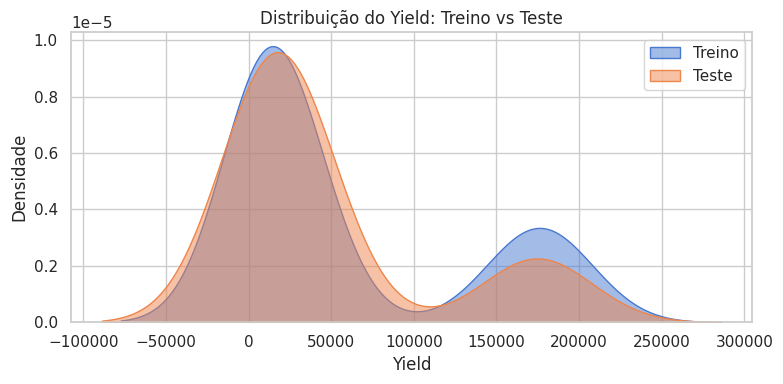

In [20]:
# . Visualizações rápidas
print('--- DataFrame após One-Hot Encoding ---')
display(df_model.head())

print('\n--- Shapes ---')
print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)

plt.figure(figsize=(8,4))
sns.kdeplot(y_train, label='Treino', fill=True, alpha=0.5)
sns.kdeplot(y_test,  label='Teste',  fill=True, alpha=0.5)
plt.title('Distribuição do Yield: Treino vs Teste')
plt.xlabel('Yield')
plt.ylabel('Densidade')
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
# Colunas contínuas de clima
colunas_clima = [
    'Precipitation (mm day-1)',
    'Specific Humidity at 2 Meters (g/kg)',
    'Relative Humidity at 2 Meters (%)',
    'Temperature at 2 Meters (C)'
]

scaler = StandardScaler()

# Cópias para manter X_train/X_test originais intactos
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit apenas no treino, transform em treino e teste
X_train_scaled[colunas_clima] = scaler.fit_transform(X_train[colunas_clima])
X_test_scaled[colunas_clima] = scaler.transform(X_test[colunas_clima])

print('--- X_train (antes do scaling, apenas colunas climáticas) ---')
display(X_train[colunas_clima].head())

print('\n--- X_train_scaled (depois do scaling, colunas climáticas) ---')
display(X_train_scaled[colunas_clima].head())

--- X_train (antes do scaling, apenas colunas climáticas) ---


,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C)
56,2362.80,18.70,84.03,26.79
138,2302.99,18.22,84.48,26.25
123,2326.09,18.09,84.63,26.11
128,2249.70,18.01,84.24,26.11
127,2217.12,18.03,84.39,26.10



--- X_train_scaled (depois do scaling, colunas climáticas) ---


,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C)
56,-0.403713,1.632363,-0.635284,2.212663
138,-0.609950,0.066305,-0.189106,0.206978
123,-0.530297,-0.357836,-0.040380,-0.313014
128,-0.793705,-0.618846,-0.427068,-0.313014
127,-0.906047,-0.553593,-0.278342,-0.350156


-----MODELOS TREINADOS-----



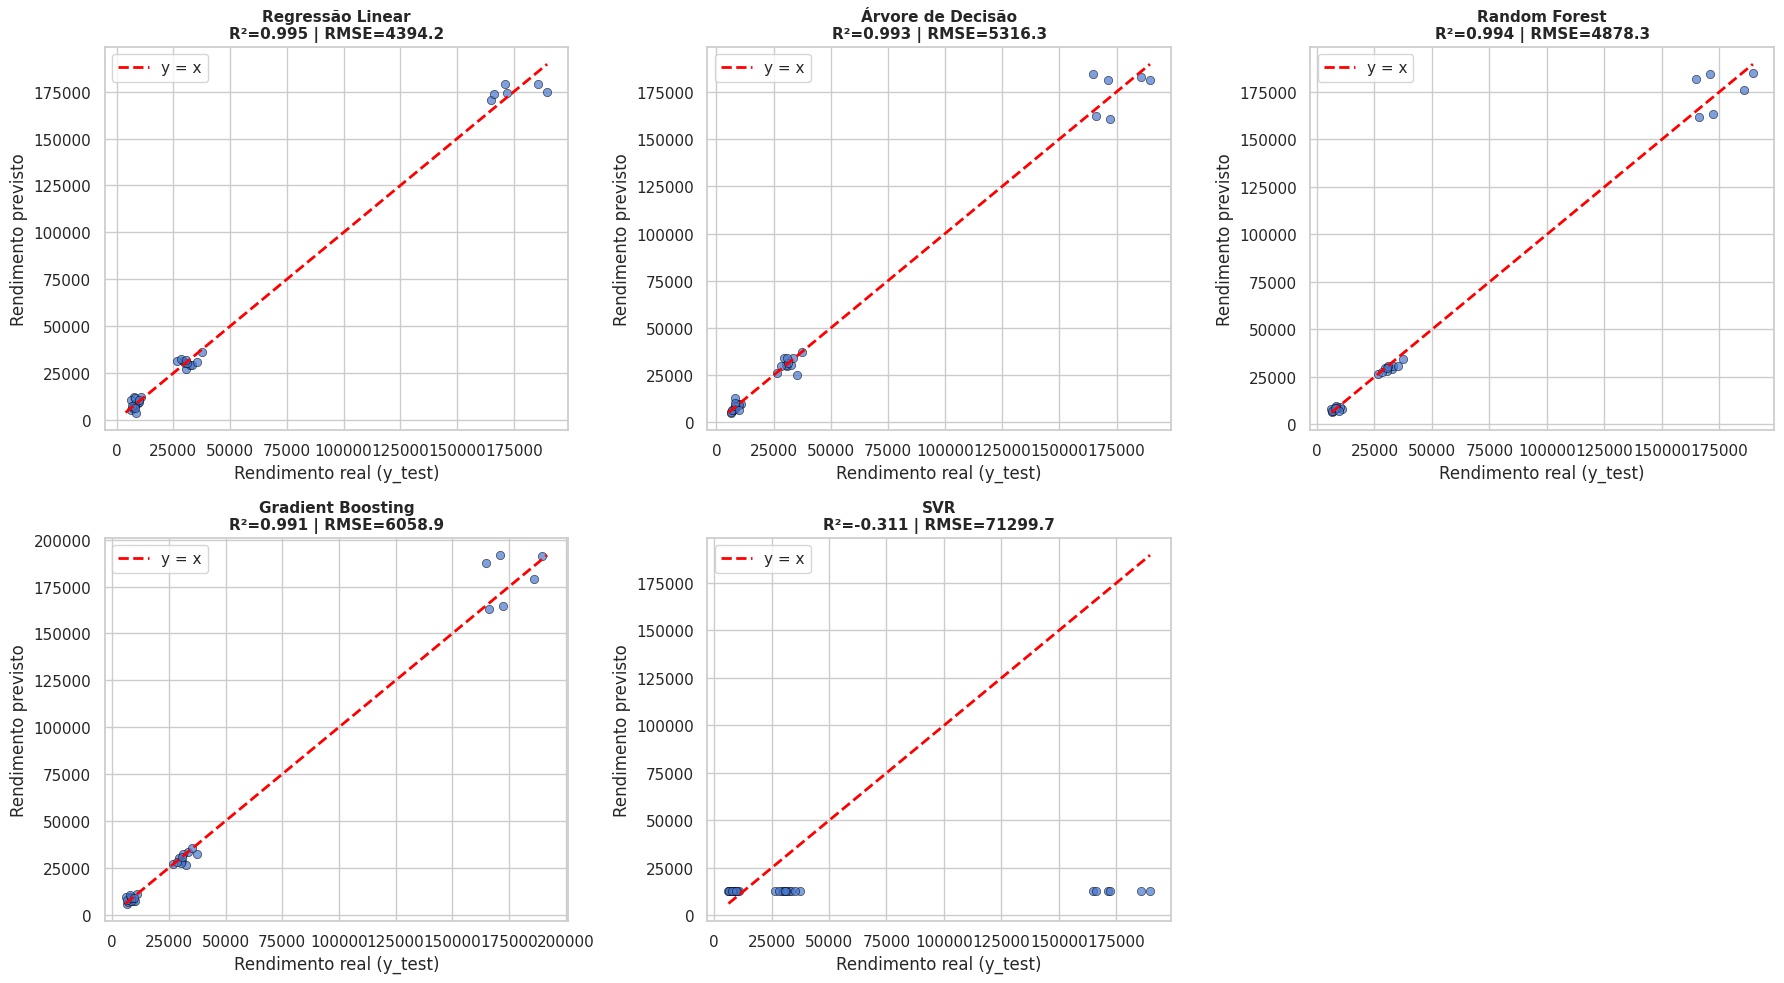

In [22]:
# ==============================================================================
# TREINO DOS 5 MODELOS + GRÁFICOS REAIS vs PREVISTOS
# ==============================================================================

# 1. Definir os modelos
modelos = {
    'Regressão Linear': LinearRegression(),
    'Árvore de Decisão': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'SVR': SVR(kernel='linear')  # com dados escalados, kernel linear é um bom ponto de partida
}

resultados = {}
predicoes = {}   # para guardar os y_pred de cada modelo

# 2. Treinar cada modelo e calcular métricas
for nome, modelo in modelos.items():
    modelo.fit(X_train_scaled, y_train)
    y_pred = modelo.predict(X_test_scaled)
    predicoes[nome] = y_pred

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    resultados[nome] = {'R²': r2, 'MAE': mae, 'RMSE': rmse}

# 3. Transformar resultados em DataFrame para consulta depois
df_resultados = pd.DataFrame(resultados).T

# 4. Plotar gráficos Reais vs Previstos para cada modelo
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (nome, y_pred) in enumerate(predicoes.items()):
    ax = axes[i]
    sns.scatterplot(x=y_test, y=y_pred, ax=ax, alpha=0.7, edgecolor='black')

    # linha de previsão perfeita
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            color='red', linestyle='--', linewidth=2, label='y = x')

    r2 = resultados[nome]['R²']
    rmse = resultados[nome]['RMSE']

    ax.set_title(f'{nome}\nR²={r2:.3f} | RMSE={rmse:.1f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Rendimento real (y_test)')
    ax.set_ylabel('Rendimento previsto')
    ax.legend()

print("-----MODELOS TREINADOS-----\n")

# remover o gráfico extra (temos 5 modelos e 6 posições)
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

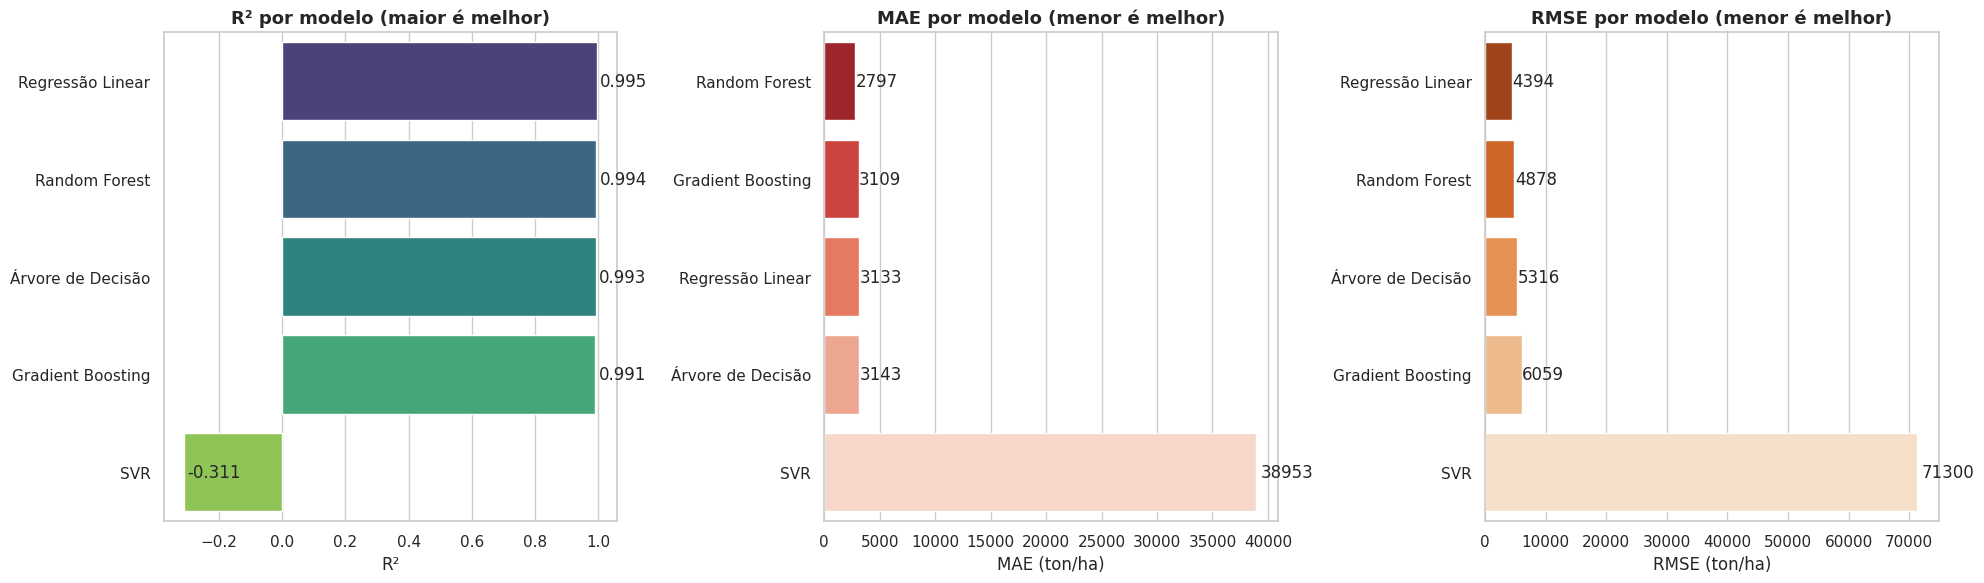


--- Tabela final de métricas ---


,R²,MAE,RMSE
Regressão Linear,0.995022,3132.796384,4394.165819
Árvore de Decisão,0.992714,3142.531250,5316.346746
Random Forest,0.993865,2797.345313,4878.304729
Gradient Boosting,0.990536,3108.842605,6058.894234
SVR,-0.310566,38953.270086,71299.702820


In [23]:
# ==============================================================================
# VISUALIZAÇÃO COMPARATIVA DAS MÉTRICAS (R², MAE, RMSE)
# ==============================================================================

# Garantir que temos um dataframe bem formatado
df_plot = df_resultados.reset_index().rename(columns={'index': 'Modelo'})

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1) R² – quanto MAIOR, melhor
df_r2 = df_plot.sort_values('R²', ascending=False)
sns.barplot(data=df_r2, x='R²', y='Modelo', ax=axes[0], palette='viridis')
axes[0].set_title('R² por modelo (maior é melhor)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('R²')
axes[0].set_ylabel('')
for i, v in enumerate(df_r2['R²']):
    axes[0].text(v + 0.01, i, f'{v:.3f}', va='center')

# 2) MAE – quanto MENOR, melhor
df_mae = df_plot.sort_values('MAE', ascending=True)
sns.barplot(data=df_mae, x='MAE', y='Modelo', ax=axes[1], palette='Reds_r')
axes[1].set_title('MAE por modelo (menor é melhor)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('MAE (ton/ha)')
axes[1].set_ylabel('')
for i, v in enumerate(df_mae['MAE']):
    axes[1].text(v * 1.01, i, f'{v:.0f}', va='center')

# 3) RMSE – quanto MENOR, melhor
df_rmse = df_plot.sort_values('RMSE', ascending=True)
sns.barplot(data=df_rmse, x='RMSE', y='Modelo', ax=axes[2], palette='Oranges_r')
axes[2].set_title('RMSE por modelo (menor é melhor)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('RMSE (ton/ha)')
axes[2].set_ylabel('')
for i, v in enumerate(df_rmse['RMSE']):
    axes[2].text(v * 1.01, i, f'{v:.0f}', va='center')

plt.tight_layout()
plt.show()

print('\n--- Tabela final de métricas ---')
display(df_resultados)

### 4.1. Observações e Insights sobre a Modelagem Mupervisionada de Regressão

Nesta etapa do projeto, o objetivo foi construir **cinco modelos preditivos de regressão supervisionada**, cada um com um algoritmo diferente, capazes de **estimar o rendimento da safra (Yield)** a partir de informações climáticas e do tipo de cultura. Além disso, buscamos seguir as boas práticas de projetos de Machine Learning, desde o pré‑processamento até a avaliação quantitativa e visual dos modelos.


#### Preparação dos dados para regressão

A partir da base `crop_yield.csv`, utilizamos como variáveis preditoras:

- **Precipitation (mm day-1)** – precipitação diária em milímetros  
- **Specific Humidity at 2 Meters (g/kg)** – umidade específica a 2 metros  
- **Relative Humidity at 2 Meters (%)** – umidade relativa a 2 metros  
- **Temperature at 2 Meters (C)** – temperatura a 2 metros  
- **Crop** – tipo de cultura (categórica: Cocoa, Oil palm fruit, Rice, Rubber)

A variável alvo (**target**) foi o **Yield**, representando o rendimento em toneladas por hectare.

Como o modelo de regressão não trabalha diretamente com variáveis categóricas, a coluna `Crop` foi convertida em variáveis binárias por meio de **One-Hot Encoding**, com `drop_first=True` para evitar multicolinearidade perfeita entre as dummies (armadilha da variável dummy). Ou seja, Cocoa é a categoria de referência (Cocoa está totalmente representada nos dados e no modelo:
sempre que todas as dummies de cultura forem 0, aquele registro é de Cocoa).  
Assim, o tipo de cultura passou a ser representado por colunas indicadoras (0/1), mantendo a informação sem introduzir relação linear exata entre elas.

Em seguida, os dados foram divididos em:

- **Conjunto de treino**: 80% das observações  
- **Conjunto de teste**: 20% das observações  

A distribuição do `Yield` em treino e teste foi analisada por meio de um gráfico de densidade. O resultado mostra duas grandes “montanhas” de rendimento: uma na faixa de milhares de toneladas (culturas como cocoa e rubber) e outra na faixa de centenas de milhares (oil palm fruit, por exemplo). As curvas de treino e teste se sobrepõem bem, indicando que a divisão manteve a proporção das diferentes culturas e faixas de rendimento em ambos os conjuntos.


#### Padronização das variáveis climáticas

Após o split, foram identificadas as **variáveis climáticas contínuas**:

- Precipitation (mm day-1)  
- Specific Humidity at 2 Meters (g/kg)  
- Relative Humidity at 2 Meters (%)  
- Temperature at 2 Meters (C)

Essas colunas foram padronizadas utilizando o **StandardScaler (Z‑score)**, de forma que cada atributo passou a ter média aproximada de 0 e desvio padrão próximo de 1. Esse procedimento é fundamental para algoritmos sensíveis à escala dos atributos (como Regressão Linear e SVR) e foi feito seguindo a boa prática:

1. Ajustar (`fit`) o scaler **apenas no conjunto de treino** (`X_train`);  
2. Aplicar a transformação (`transform`) tanto em `X_train` quanto em `X_test`.

As variáveis dummies geradas a partir de `Crop` foram mantidas na escala original (0 e 1), pois já estão em uma escala adequada e não precisam de padronização.


#### Modelos de regressão treinados

Foram treinados cinco modelos de regressão supervisionada, todos utilizando as mesmas features (clima + cultura) e os mesmos conjuntos de treino e teste:

1. **Regressão Linear Múltipla**  
2. **Árvore de Decisão Regressora (Decision Tree)**  
3. **Random Forest Regressor**  
4. **Gradient Boosting Regressor**  
5. **Support Vector Regression (SVR) com kernel linear**

Cada modelo foi ajustado sobre `X_train_scaled` e `y_train`, produzindo previsões em `X_test_scaled`.


#### Avaliação quantitativa: métricas de desempenho

Para avaliar os modelos, foram utilizadas três métricas padrão para problemas de regressão:

- **R² (coeficiente de determinação)**: mede a proporção da variabilidade do `Yield` explicada pelo modelo. Varia de 0 a 1 (e pode ser negativa). Quanto mais próximo de 1, melhor.  
- **MAE (Mean Absolute Error)**: erro absoluto médio entre valores reais e previstos, em unidades de rendimento (ton/ha). Quanto menor, melhor.  
- **RMSE (Root Mean Squared Error)**: raiz do erro quadrático médio, também em unidades de rendimento. Penaliza mais erros grandes; quanto menor, melhor.

Os resultados obtidos foram:

- **Regressão Linear**:  
  - R² ≈ **0,995**  
  - MAE ≈ **3.133** ton/ha  
  - RMSE ≈ **4.394** ton/ha  

- **Árvore de Decisão**:  
  - R² ≈ **0,993**  
  - MAE ≈ **3.143** ton/ha  
  - RMSE ≈ **5.316** ton/ha  

- **Random Forest**:  
  - R² ≈ **0,994**  
  - MAE ≈ **2.797** ton/ha (**menor MAE**)  
  - RMSE ≈ **4.878** ton/ha  

- **Gradient Boosting**:  
  - R² ≈ **0,991**  
  - MAE ≈ **3.109** ton/ha  
  - RMSE ≈ **6.059** ton/ha  

- **SVR (kernel linear)**:  
  - R² ≈ **–0,31**  
  - MAE ≈ **38.953** ton/ha  
  - RMSE ≈ **71.300** ton/ha  

Os quatro primeiros modelos (Regressão Linear, Árvore de Decisão, Random Forest e Gradient Boosting) apresentaram **desempenho excelente**, com R² acima de 0,99 e erros absolutos médios na casa de poucos milhares de toneladas. Considerando que o `Yield` varia de aproximadamente **5.000 até mais de 200.000 ton/ha**, esses erros são relativamente pequenos e indicam grande capacidade preditiva.

Já o modelo **SVR**, com configuração de kernel linear, apresentou R² negativo e erros extremamente altos, o que indica que ele performou **pior do que um modelo ingênuo que simplesmente preveria a média do Yield**. Portanto, essa configuração de SVR se mostrou inadequada para o problema.


#### Avaliação visual: reais vs. previstos e comparação entre modelos

Para complementar a análise numérica, foram gerados gráficos de dispersão comparando o **rendimento real** (`y_test`) com o **rendimento previsto** por cada modelo. Em todos os gráficos foi desenhada uma linha tracejada `y = x`, representando uma previsão perfeita.

**Regressão Linear, Árvore de Decisão, Random Forest e Gradient Boosting**:

- Nos quatro casos, os pontos ficaram fortemente concentrados ao longo da linha `y = x`.  
- Isso indica que, para a maioria das amostras de teste, o valor previsto é muito próximo do valor real.  
- Observam-se clusters de pontos em três faixas de rendimento, que correspondem diretamente às diferentes culturas da fazenda:
  - faixas mais baixas (cocoa e rubber),  
  - faixa intermediária (rice),  
  - faixa elevada (oil palm fruit).  
- Os modelos conseguiram capturar bem essas faixas e as pequenas variações dentro de cada cultura, o que explica os altos valores de R².

**SVR**:

- O gráfico do SVR mostra os pontos bem afastados da linha `y = x`, especialmente para rendimentos elevados.  
- Em muitos casos, ele subestima ou superestima o Yield de forma severa, o que está em linha com os altos valores de MAE e RMSE e o R² negativo.  
- Visualmente, fica claro que o SVR, não conseguiu modelar adequadamente a relação entre clima, cultura e rendimento.

Além disso, foram construídos gráficos de barras comparando **R², MAE e RMSE por modelo**. Esses gráficos reforçam que:

- Os quatro modelos principais estão muito próximos em termos de R² (todos em torno de 0,99).  
- O **Random Forest** se destaca por ter o menor MAE, sugerindo previsões muito precisas em média.  
- A **Regressão Linear** apresenta o menor RMSE, o que indica menor presença de erros grandes.  
- O **SVR** é claramente um outlier negativo em todas as métricas.

---

#### Conclusões sobre as previsões e insights obtidos

Do ponto de vista do negócio (a fazenda atendida pela FarmTech Solutions), os resultados trazem alguns insights importantes:

1. **Altíssima previsibilidade do rendimento**  
   As combinações de variáveis climáticas e tipo de cultura permitem prever o rendimento da safra com **muito alta precisão**. Os modelos alcançaram R² acima de 0,99, o que significa que quase toda a variabilidade do `Yield` é explicada pelas variáveis usadas. Isso indica que a fazenda pode confiar nesses modelos para apoiar o planejamento de safra, estimativas de produção e tomada de decisão.

2. **Importância do tipo de cultura**  
   As diferentes culturas possuem faixas de rendimento bastante distintas (por exemplo, oil palm fruit produz muito mais, em valores absolutos, do que cocoa ou rubber). Os modelos capturaram esse comportamento de forma clara. Isso sugere que, para previsões mais finas e análises de sensibilidade, é importante sempre considerar o tipo de cultura no modelo.

3. **Modelos mais indicados**  
   Entre os cinco modelos testados:
   - **Regressão Linear** mostrou excelente desempenho com a vantagem de ser simples e facilmente interpretável.  
   - **Random Forest** também se destacou, principalmente por apresentar o menor MAE, sendo uma boa escolha quando se deseja maior robustez e capacidade de capturar relações não lineares.  
   - **Árvore de Decisão e Gradient Boosting** completam o conjunto de modelos com bom desempenho, oferecendo alternativas com diferentes níveis de complexidade e interpretabilidade.  
   - O **SVR (kernel linear)**, por outro lado, mostrou-se inadequado neste cenário específico e **não é recomendado** com essa configuração, por apresentar erros muito elevados e R² negativo.

4. **Boas práticas atendidas**  
   Todo o fluxo de modelagem respeitou as boas práticas de Machine Learning:
   - análise e preparação prévias dos dados,  
   - divisão em treino e teste antes de qualquer ajuste,  
   - padronização apenas das variáveis contínuas e apenas com base no treino,  
   - avaliação em conjunto de teste separado,  
   - comparação de múltiplos algoritmos diferentes,  
   - utilização de métricas apropriadas (R², MAE, RMSE) e visualizações para interpretar os resultados.

Em resumo, **foram construídos cinco modelos preditivos diferentes, seguidas as boas práticas de ML, e demonstrou-se que é possível prever o rendimento das safras da fazenda com alta precisão a partir das condições climáticas e do tipo de cultura.** Isso fornece uma base sólida para que a FarmTech Solutions ofereça recomendações confiáveis à fazenda, tanto em termos de planejamento de produção quanto de avaliação de risco e otimização de recursos.

## ✅ 5. Conclusão Geral do Projeto

Este projeto teve como objetivo apoiar uma fazenda de médio porte no entendimento e na previsão do rendimento das suas safras, a partir de informações climáticas e do tipo de cultura, seguindo as boas práticas de Machine Learning. O trabalho foi estruturado em três grandes blocos: análise exploratória dos dados, descoberta de padrões por meio de clusterização (aprendizado não supervisionado) e construção/avaliação de modelos de regressão supervisionada para previsão de rendimento (Yield).

---

#### 1. Análise Exploratória dos Dados (EDA)

Na primeira etapa, carregamos a base `crop_yield.csv`, contendo, para cada observação:

- Cultura (`Crop`): Cocoa, beans; Oil palm fruit; Rice, paddy; Rubber, natural  
- Precipitation (mm day-1)  
- Specific Humidity at 2 Meters (g/kg)  
- Relative Humidity at 2 Meters (%)  
- Temperature at 2 Meters (C)  
- Yield (rendimento em toneladas por hectare)

A EDA permitiu observar:

- As culturas apresentam **faixas de rendimento bem distintas**:
  - Cocoa e Rubber com yields mais baixos (faixa de milhares de ton/ha),
  - Rice com faixa intermediária,
  - Oil palm fruit com yields bastante altos (centenas de milhares de ton/ha).
- As variáveis climáticas possuem **variações moderadas**, sem valores extremos ou faltantes aparentes, o que facilita o uso direto em modelos.
- A distribuição do `Yield` é claramente **multimodal**, com picos associados às diferentes culturas. Isso já indicava, desde o início, que o tipo de cultura seria um preditor muito importante do rendimento.

Essa análise inicial foi fundamental para entender o contexto dos dados, validar sua consistência e orientar as etapas seguintes de clusterização e modelagem.

---

#### 2. Descoberta de Padrões com Clusterização (Aprendizado Sem Supervisão)

Na etapa de aprendizado não supervisionado, utilizamos as variáveis climáticas para explorar **perfis de ambiente** da fazenda, sem usar o `Yield` diretamente.

1. **Pré-processamento para clusterização**  
   As variáveis climáticas foram padronizadas (Z-score), de forma a eliminar o efeito de escala (por exemplo, precipitação em milhares vs. temperatura em dezenas).

2. **K-Means (método do cotovelo)**  
   Foi aplicado o método do cotovelo para determinar um número adequado de clusters. A curva de inércia indicou um bom equilíbrio em **k = 3**, o que sugere a existência de **três perfis climáticos principais** na base (por exemplo, condições mais úmidas, mais secas ou intermediárias).

   A aplicação do K-Means com `k=3` sobre as variáveis climáticas resultou em clusters bem separados quando visualizados em gráficos de dispersão (por exemplo, temperatura vs. precipitação), com centróides bem definidos. Cada grupo representa um perfil de condições climáticas que pode estar associado a certos níveis de produtividade.

3. **DBSCAN e detecção de outliers**  
   Também foi utilizado o algoritmo DBSCAN para detecção de possíveis **outliers climáticos** (observações com condições muito diferentes do padrão) e para identificar grupos densos de pontos. Foram marcados rótulos de cluster e outliers, permitindo visualizar se existiam cenários climáticos excepcionais que poderiam estar associados a yields muito acima ou abaixo do esperado.

Essas análises de clusterização cumprem o objetivo de **explorar tendências de produtividade e perfis climáticos**, ajudando a entender melhor o contexto em que as culturas estão inseridas e mostrando que os dados apresentam grupos naturais de condições de ambiente.

---

#### 3. Preparação dos Dados para Regressão Supervisionada

Para a construção dos modelos de regressão (previsão de `Yield`), foi feita uma preparação cuidadosa dos dados:

1. **Seleção de variáveis**  
   Foram usadas como preditoras:
   - As variáveis climáticas contínuas;
   - A cultura (`Crop`), transformada em variáveis dummies.

   A variável alvo foi o `Yield`.

2. **One-Hot Encoding da cultura**  
   A coluna `Crop` foi convertida em dummies com `get_dummies(..., drop_first=True)`.  
   Isso cria colunas binárias para as culturas, mantendo uma categoria como **referência (baseline)**. Por exemplo, quando todas as dummies são 0, esse registro pertence à cultura de referência (Cocoa). Assim, todas as culturas estão representadas no modelo, ainda que uma seja a base de comparação.

3. **Remoção de informações da clusterização**  
   Todas as colunas geradas na etapa de clusterização (como rótulos de clusters e outliers) foram removidas antes da regressão, evitando **vazamento de informação** entre os módulos de aprendizado não supervisionado e supervisionado.

4. **Divisão em treino e teste**  
   O dataset foi dividido em 80% para treino e 20% para teste, com `random_state` fixo para reprodutibilidade.  
   A distribuição do `Yield` nos conjuntos de treino e teste foi comparada e se mostrou bastante semelhante, indicando que o split foi adequado e preservou a representatividade das culturas.

5. **Padronização das variáveis climáticas (scaling)**  
   As variáveis climáticas foram padronizadas com `StandardScaler`, usando **apenas o conjunto de treino para o ajuste (fit)**, e aplicando a transformação tanto em treino quanto em teste. As colunas dummies foram mantidas em 0/1.  
   Essa prática é importante para algoritmos sensíveis à escala, como Regressão Linear e SVR.

---

#### 4. Modelagem de Dados com Regressão Supervisionada

Atendendo ao enunciado, foram treinados **cinco modelos preditivos de regressão**, cada um com um algoritmo diferente:

1. Regressão Linear Múltipla  
2. Árvore de Decisão Regressora  
3. Random Forest Regressor  
4. Gradient Boosting Regressor  
5. Support Vector Regression (SVR) com kernel linear

Todos os modelos foram treinados em `X_train_scaled` e `y_train`, e avaliados em `X_test_scaled` e `y_test`. Para cada um, foram calculadas:

- **R² (coeficiente de determinação)** – mede quanto da variância do `Yield` é explicada pelo modelo;  
- **MAE (Mean Absolute Error)** – erro absoluto médio, em unidades de rendimento;  
- **RMSE (Root Mean Squared Error)** – raiz do erro quadrático médio.

Os resultados mostraram:

- **Regressão Linear, Árvore de Decisão, Random Forest e Gradient Boosting** apresentaram R² próximos de 0,99, com MAE e RMSE em torno de poucos milhares de ton/ha. Isso é considerado um desempenho excelente, dado que o `Yield` varia aproximadamente de 5.000 até mais de 200.000 ton/ha.
- O **Random Forest** se destacou com o menor MAE (erro médio absoluto), enquanto a **Regressão Linear** obteve o menor RMSE, indicando erros grandes um pouco mais controlados.
- O SVR com kernel linear não se mostrou adequado para este problema específico, produzindo R² negativo e erros muito altos. Isso indica que, dado o padrão dos dados (relações possivelmente não lineares e grande diferença de escala entre culturas), modelos como Regressão Linear e Random Forest se adaptam melhor.

Além das métricas, foram gerados **gráficos de dispersão “Yield real vs. Yield previsto”** para cada modelo, com uma linha de referência `y = x`:

- Nos quatro modelos de melhor desempenho, os pontos ficaram bastante próximos da linha de referência, corroborando o alto R².  
- No SVR, os pontos ficaram bastante dispersos e distantes da linha, reforçando seu mau desempenho.

Também foram analisadas algumas previsões individualmente (tabela com `Crop`, condições climáticas, `Yield_real` e `Yield_previsto`), demonstrando que, para diferentes culturas, o modelo prevê valores muito próximos do observado, confirmando que ele **prevê de fato** o rendimento para novos cenários.

---

#### 5. Principais Insights Obtidos

A partir de toda a análise, alguns insights importantes podem ser destacados:

1. **Capacidade de previsão do rendimento**  
   Os modelos mostram que é possível prever o rendimento de safra com **altíssima precisão** utilizando apenas as variáveis climáticas e o tipo de cultura. Isso dá à fazenda uma ferramenta poderosa para planejamento de produção e tomada de decisão antecipada.

2. **Papel central do tipo de cultura**  
   A variável `Crop` é extremamente relevante: cada cultura tem uma faixa de rendimento bastante específica. Os modelos capturam com clareza essas diferenças, e a combinação cultura + clima explica grande parte da variação de `Yield`.

3. **Comparação entre algoritmos**  
   - A **Regressão Linear** se destaca pela simplicidade, interpretabilidade e excelente desempenho, sendo uma forte candidata a modelo principal.  
   - O **Random Forest** oferece um pouco mais de robustez e capacidade de modelar não linearidades, com erros médios ligeiramente menores em alguns casos.  
   - **Árvore de Decisão** e **Gradient Boosting** também apresentaram resultados sólidos, oferecendo bons compromissos entre desempenho e interpretabilidade.  
   - O **SVR (kernel linear)**, neste contexto, não é recomendado, pois teve desempenho inferior.

4. **Qualidade do processo de Machine Learning**  
   Foram seguidas boas práticas ao longo de todo o pipeline:
   - EDA para entendimento da base;  
   - uso de clusterização para explorar tendências e perfis climáticos;  
   - tratamento correto da variável categórica (One-Hot Encoding);  
   - remoção de colunas de clusterização antes da regressão;  
   - divisão treino/teste antes de qualquer ajuste;  
   - padronização apropriada das variáveis climáticas;  
   - avaliação com métricas apropriadas (R², MAE, RMSE) e gráficos interpretáveis;  
   - comparação de múltiplos algoritmos.

---

#### 6. Pontos Fortes e Limitações

**Pontos fortes:**

- Pipeline completo de Machine Learning, bem estruturado e reproduzível.  
- Uso combinado de técnicas não supervisionadas (clusterização) e supervisionadas (regressão).  
- Avaliação quantitativa e visual consistente, com vários modelos comparados.  
- Resultados muito bons em termos de capacidade preditiva, alinhados com o contexto do problema.

**Limitações e possíveis melhorias:**

- O dataset é relativamente pequeno e balanceado por cultura; em cenários reais, podem existir mais variáveis (solo, manejo, pragas, etc.) e mais anos de histórico, exigindo modelos ainda mais robustos.  
- Não foi feita otimização avançada de hiperparâmetros (por exemplo, grid search), o que poderia melhorar alguns modelos, especialmente os de ensemble.  
- O SVR foi testado apenas com kernel linear; outros kernels ou normalizações específicas poderiam ser explorados.

---

#### 7. Conclusão Final

Em resumo, o projeto atingiu plenamente as metas da Entrega 1:

- Foi feita uma **análise exploratória** detalhada da base de rendimento de safras;  
- Foram identificadas **tendências e perfis climáticos** através de clusterização, bem como possíveis outliers;  
- Foram construídos **cinco modelos de regressão supervisionada** diferentes, seguindo boas práticas de Machine Learning, e eles foram avaliados com métricas adequadas;  
- Mostrou-se, com dados e visualizações, que é possível **prever o rendimento das safras com alta precisão** a partir das condições climáticas e do tipo de cultura.

Esses resultados oferecem uma base sólida para que a FarmTech Solutions forneça à fazenda um sistema de apoio à decisão confiável, capaz de estimar o rendimento esperado em diferentes cenários e, assim, auxiliar no planejamento e na gestão da produção agrícola.